In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("the_oscar_award.csv")
df.head()

,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner
0,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Noose,False
1,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Patent Leather Kid,False
2,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Last Command,True
3,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Way of All Flesh,True
4,1927,1928,1,ACTRESS,ACTRESS IN A LEADING ROLE,Louise Dresser,A Ship Comes In,False


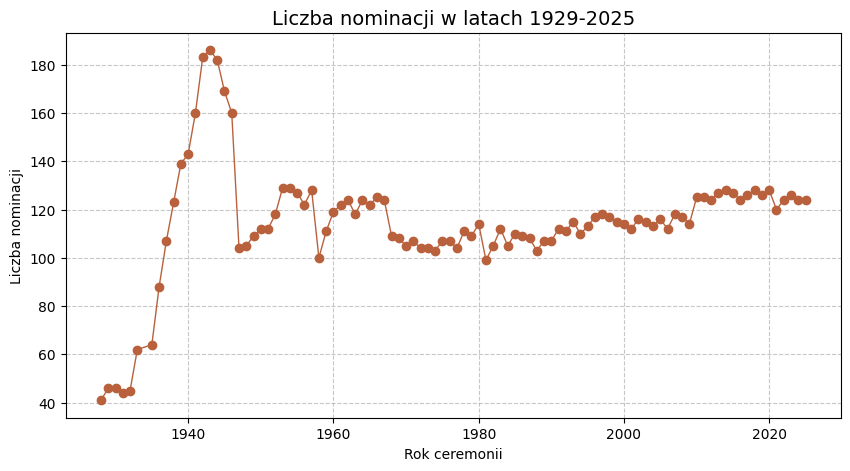

In [4]:
trend = df.groupby('year_ceremony').size()

plt.figure(figsize=(10, 5))
trend.plot(kind='line',  marker='o', color="#b8613c", linewidth=1)

plt.title('Liczba nominacji w latach 1929-2025', fontsize=14)
plt.ylabel('Liczba nominacji')
plt.xlabel('Rok ceremonii')
plt.grid( linestyle='--', alpha=0.7)
plt.show()

C:\Users\justy\AppData\Local\Temp\ipykernel_21160\1933224864.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_ludzie.values, y=top_ludzie.index, palette='flare')


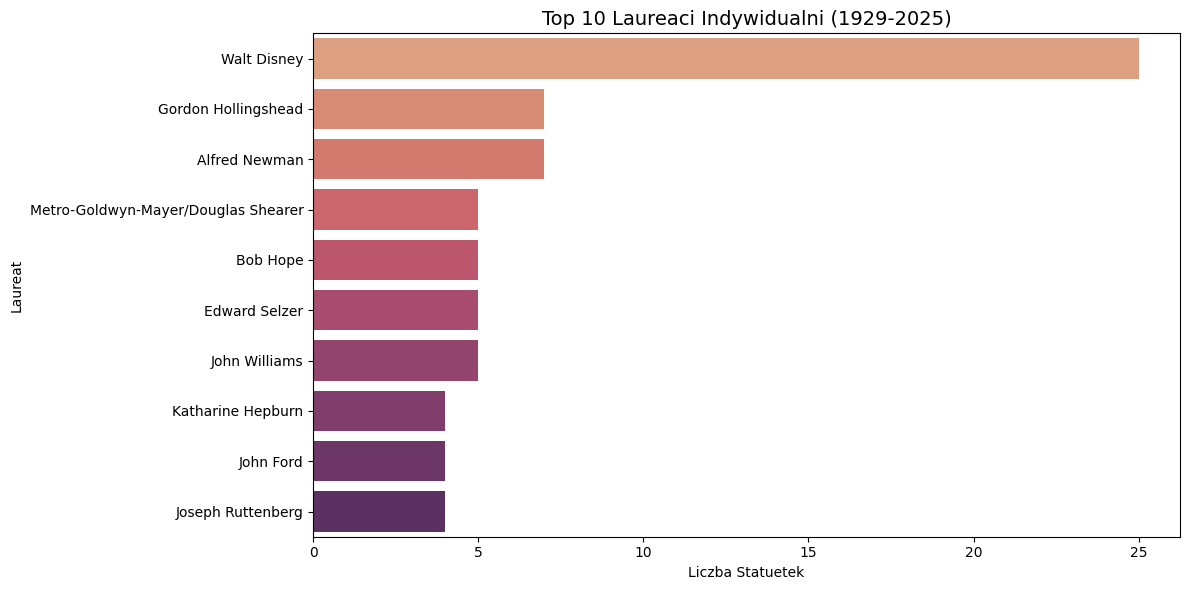

In [5]:
winners = df[df['winner'] == True].copy()

instytucje = ['Italy', 'France', 'Metro-Goldwyn-Mayer', 'Warner Bros.', 'Paramount', 'Columbia', 'Universal', 'Japan', 'Spain' ]

df_ludzie = winners[~winners['name'].isin(instytucje)]


top_ludzie = df_ludzie['name'].value_counts().head(10)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_ludzie.values, y=top_ludzie.index, palette='flare')

plt.title('Top 10 Laureaci Indywidualni (1929-2025)', fontsize=14)
plt.xlabel('Liczba Statuetek')
plt.ylabel('Laureat')
plt.tight_layout()
plt.show()


C:\Users\justy\AppData\Local\Temp\ipykernel_21160\3586559041.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_films.head(10), x='wins', y='film', palette='flare')


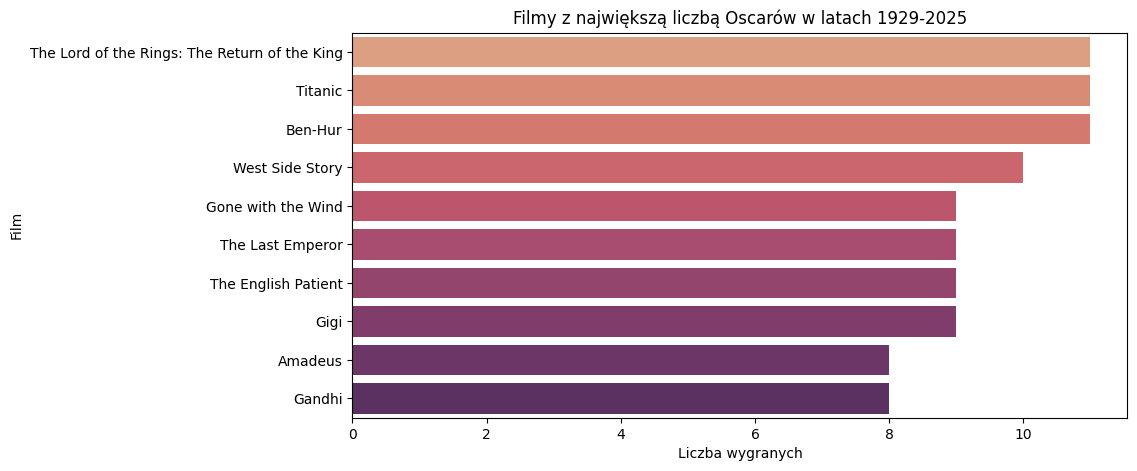

In [6]:
top_films = df[df['winner'] == True].groupby(['year_ceremony', 'film']).size().reset_index(name='wins')
top_films = top_films.sort_values(by='wins', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_films.head(10), x='wins', y='film', palette='flare')
plt.title('Filmy z największą liczbą Oscarów w latach 1929-2025')
plt.xlabel('Liczba wygranych')
plt.ylabel('Film')
plt.show()

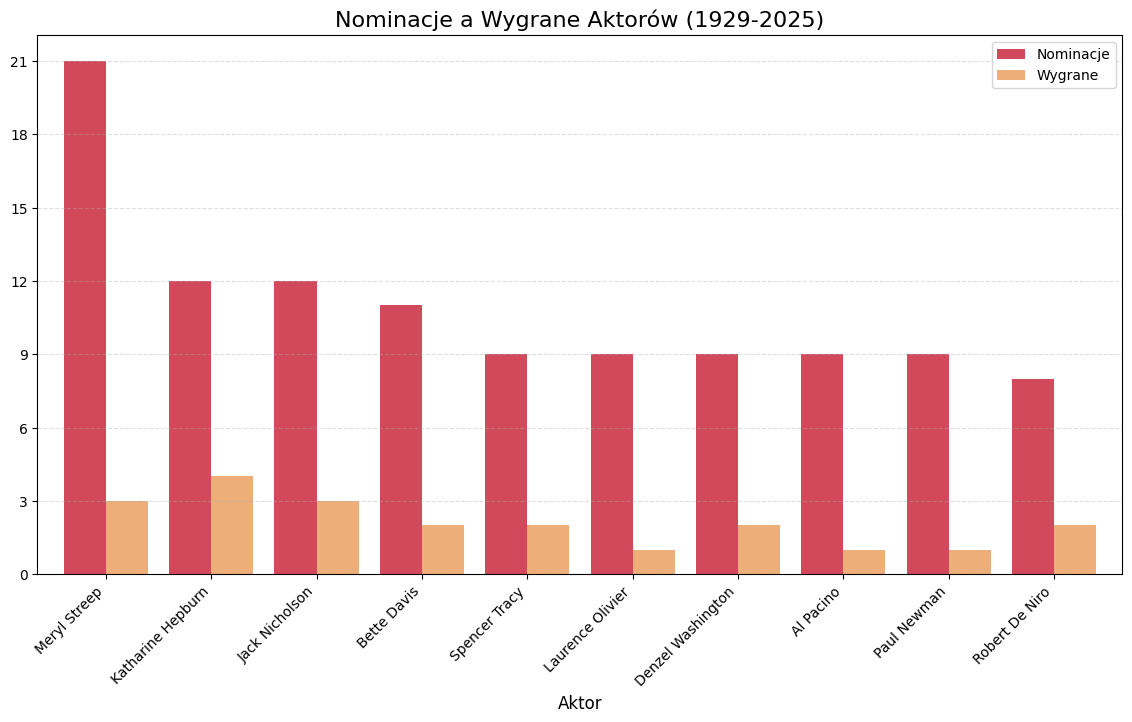

In [7]:
import matplotlib.ticker as ticker
acting_all = df[df['canon_category'].str.contains('ACTOR|ACTRESS', case=False, na=False)]

actor_stats = acting_all.groupby('name').agg(
    nominations=('winner', 'count'),
    wins=('winner', 'sum')
).sort_values(by='nominations', ascending=False).head(10)

ax = actor_stats.plot(kind='bar', figsize=(14, 7), color=["#d1495b", "#edae79"], width=0.8)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('Nominacje a Wygrane Aktorów (1929-2025)', fontsize=16)
plt.xlabel('Aktor', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(['Nominacje', 'Wygrane'])